# Introduction

This notebook is the next step in preparing **supportive features** for **GRU model training** to predict **BRK stock prices**. The focus is on **finding unusual market behaviour** and creating **simple anomaly signals** that can be used in the prediction model.
Initially, we planned to use BRK stock prices from the [FNSPID Financial News Dataset](https://github.com/Zdong104/FNSPID_Financial_News_Dataset?utm_source=chatgpt.com), but it only covers data up to 2020 year. Therefore, we replaced it with a **BRK stock price dataset from  [Kaggle](https://www.kaggle.com/datasets/umerhaddii/berkshire-hathaway-stock-price-data)**, which provides a **longer historical record up to 2025 year**, allowing for better anomaly detection and feature preparation.

---

# Methodology

## 1. Data Preparation
We begin by **loading historical BRK stock price data** to prepare **anomaly detection features**. The **date column is converted to UTC format**, and **data after a selected date is removed** to ensure that the **anomaly detection data** and the **news sentiment analysis dataset acquired in the previous step** end on the **same date**, allowing **both datasets to be used together consistently**.

## 2. Anomaly Detection Using TSPulse
When the data is prepared, we create a **pre-trained TSPulse anomaly detection model**, which learns **normal stock price behaviour** and generates **anomaly scores**.

The model **predicts what the stock price should be** at each point in time based on **historical data**, and then **compares these predicted values with the actual prices**.
The **difference between the actual and predicted prices** is used to calculate the **anomaly score**, with **larger differences** indicating more **unusual price behavior.**

After computing the anomaly scores, we apply an **adaptive threshold** to identify anomalies and flag each time step as **anomaly detected** or **anomaly not detected**.

Finally, we create a separate **DataFrame containing only the detected anomalies** for further analysis.

## 3. Anomaly Feature Refinement
To improve the output produced by the TSPulse model, we **further process the detected anomalies** using **rolling smoothing** and calculate **forward-looking statistics**, such as **5-day price changes** and **volatility**.

This allows us to label the anomalies with more meaningful categories:
1. **Neutral**: Regular anomalies with no significant future effect.
2. **Uncertainty spikes**: Anomalies followed by high future volatility.
3. **Price dislocations**: Anomalies followed by large price movements.

These **labeled anomalies** are then used as **supportive features** for **GRU model training**.


---

# Initial Anomaly Detection Implementation

## Install dependencies
Uncomment the code in the cell below to install the dependencies required for this notebook.

In [1]:
# !pip install pandas numpy matplotlib scikit-learn torch

In [2]:
# !pip install git+https://github.com/IBM/tsfm.git

## Import dependencies

In [3]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tsfm_public.models.tspulse.modeling_tspulse import TSPulseForReconstruction
from tsfm_public.toolkit.ad_helpers import AnomalyScoreMethods
from tsfm_public.toolkit.time_series_anomaly_detection_pipeline import TimeSeriesAnomalyDetectionPipeline

## Load Dataset

In [4]:
# Load CSV
df = pd.read_csv("./Inputs/BRK_Pre_Processed.csv")

# Verify that the dataset is loaded by displaying 5 top rows 
df.head()

,date,open,high,low,close,adj_close,volume
0,1996-05-09,22.200001,24.400000,22.200001,23.200001,23.200001,4290000.0
1,1996-05-10,24.000000,24.200001,23.600000,24.000000,24.000000,1060000.0
2,1996-05-13,24.000000,24.100000,23.299999,23.900000,23.900000,700000.0
3,1996-05-14,24.000000,24.100000,23.100000,23.600000,23.600000,310000.0
4,1996-05-15,23.600000,23.700001,23.000000,23.200001,23.200001,545000.0


## Aligning Data End Dates

The news dataset for **BRK** ends on **December 12, 2023, at 10 PM**, while the stock price history extends to **August 12, 2025**.
To ensure consistency, we **remove all stock price entries after December 12, 2023, at 10 PM**, so both datasets **share the same end date**.

In [5]:
# Convert 'date' column to 'UTC' format.
df["date"] = pd.to_datetime(df["date"], utc=True)

# Create date and time cutoff point
date_time_cutoff_point = pd.Timestamp("2023-12-16 22:00:00", tz="UTC")

# Remove entries after the cuttof point
df = df[df["date"] <= date_time_cutoff_point].copy()

---

## Create Computational Device

To speed up processing with the **TSPulse model**, it is preferable to use a **GPU** instead of a **CPU**.

Therefore, we **start with creating the device and setting it to CPU by default**, then **check if a GPU is available** and switch to it if possible.

Finally, we **print the device being used**.

In [6]:
# Create computational device and set it to 'CPU'
device = "cpu"

# Check if GPU is available and set device to it if true
if (torch.cuda.is_available()):
    device = "cuda"

# Print the state of the device for verification
print(f"Device set to: {device}")

Device set to: cuda


## Create TSPulse Model and Pipeline

In this step, we **create the TSPulse model** following the guidelines provided on **HuggingFace**, and **move the model to the chosen computational device**.

Next, we **set up the anomaly detection pipeline**, which will be used to **identify anomalies in the BRK stock price dataset**.

In [7]:
# Create TSPulse model
tspulse = TSPulseForReconstruction.from_pretrained(
    "ibm-granite/granite-timeseries-tspulse-r1",
    num_input_channels=1,
    revision="main",
    mask_type="user",
)

# Move TSPulse to the current computational device
tspulse = tspulse.to(device)

# Create pipeline for anomaly detection
pipeline = TimeSeriesAnomalyDetectionPipeline(
    tspulse,
    timestamp_column="date",
    target_columns=["close"],
    prediction_mode=[
        AnomalyScoreMethods.TIME_RECONSTRUCTION.value,
    ],
    aggregation_length=32,
    aggr_function="max",
    smoothing_length=6,
    least_significant_scale=0.001,
    least_significant_score=0.01,
)

Device set to use cuda:0


## Detect Anomalies in the BRK Dataset Using TSPulse

After creating the **TSPulse model** and setting up the **pipeline**, we use it to **detect anomalies in the BRK stock price dataset**.

In [8]:
# Create DataFrame that holds the data from the originla DataFrame + anomaly_score for each entry.
# Then cal the pipeline to generate anomaly_score for each entry
tspulse_result_df = pipeline(df, batch_size=256, predictive_score_smoothing=False)

# Verify that tspulse_result_df has new column with anomaly scores in it
tspulse_result_df.head()

,date,open,high,low,close,adj_close,volume,anomaly_score
0,1996-05-09 00:00:00+00:00,22.200001,24.400000,22.200001,23.200001,23.200001,4290000.0,0.005864
1,1996-05-10 00:00:00+00:00,24.000000,24.200001,23.600000,24.000000,24.000000,1060000.0,0.007818
2,1996-05-13 00:00:00+00:00,24.000000,24.100000,23.299999,23.900000,23.900000,700000.0,0.009773
3,1996-05-14 00:00:00+00:00,24.000000,24.100000,23.100000,23.600000,23.600000,310000.0,0.011727
4,1996-05-15 00:00:00+00:00,23.600000,23.700001,23.000000,23.200001,23.200001,545000.0,0.011727


We can see that the **TSPulse model generates an anomaly score for each entry**.
Next, we will **apply an adaptive threshold** to these scores to **filter out entries that do not qualify as anomalies** in the dataset.

## Filtering Anomalies with Adaptive Threshold

In this step, we identify unusual price points by applying an **adaptive threshold** to the anomaly scores.
Using this threshold, we **consider only the top 10% of the highest anomaly scores** as anomalies, capturing the most unusual price movements.
These entries are then flagged with a **binary indicator**:
- **Normal**: 0
- **Anomaly**: 1


In [9]:
# Create threshold that is going to be used to filter out entries that do not qualify to be an anomaly
threshold = tspulse_result_df["anomaly_score"].quantile(0.9)

tspulse_result_df["anomaly"] = (tspulse_result_df["anomaly_score"] > threshold).astype(int)

tspulse_result_df["anomaly"].value_counts() 

anomaly
0    6254
1     695
Name: count, dtype: int64

After applying the adaptive threshold, we observe that **695 data points are identified as anomalies**, while **6,254 points are classified as normal**.

The next step is to **create a separate DataFrame containing only the detected anomalies** for further processing.

In [10]:
# Create new DataFrame that hold entries that are qualified to be an anomaly
anomalies_only_df = tspulse_result_df[tspulse_result_df["anomaly"] == 1]

# Display length of the dataframe to confirm that it 
# holds the exact number of entries as the number of anomalies detected in the previous step
print(f"Detected anomalies: {len(anomalies_only_df)}")

Detected anomalies: 695


In [11]:
anomalies_only_df.head()

,date,open,high,low,close,adj_close,volume,anomaly_score,anomaly
3115,2008-09-24 00:00:00+00:00,90.000000,90.000000,88.000000,89.500000,89.500000,2250000.0,0.111349,1
3116,2008-09-25 00:00:00+00:00,89.500000,90.080002,87.820000,88.800003,88.800003,1540000.0,0.113510,1
3117,2008-09-26 00:00:00+00:00,86.800003,89.489998,86.639999,88.500000,88.500000,1050000.0,0.111173,1
3139,2008-10-28 00:00:00+00:00,70.599998,72.779999,68.160004,70.199997,70.199997,3295000.0,0.118057,1
3140,2008-10-29 00:00:00+00:00,71.800003,74.360001,71.199997,73.900002,73.900002,2010000.0,0.133705,1


Visualising Detected Anomalies in BRK Closing Prices
The final step of this section is to **visualise the detected anomalies** on a price chart.
We plot the **BRK closing price over the full time period**, highlight the **detected anomalies**, and overlay the **anomaly scores and adaptive threshold**.
- **Blue Graph**: Represents the closing price over time.
- **Red Markers**: Represent points identified as anomalies.
- **Orange Line**: Represents the anomaly score.
- **Dashed Red Line**: Represents the adaptive threshold.

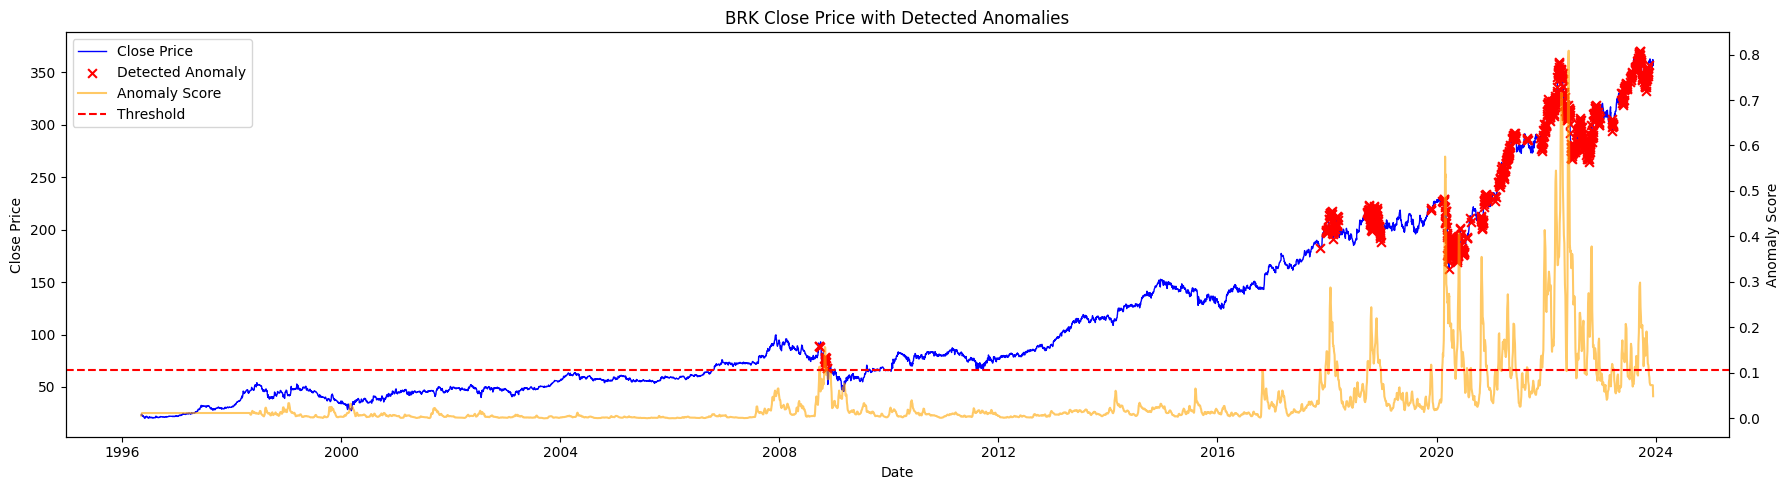

In [12]:
# Create graph
fig, ax1 = plt.subplots(figsize=(18, 5))

# Blue Graph: Plot 'close price' from 'tspulse_result_df' DataFrame
ax1.plot(tspulse_result_df["date"], tspulse_result_df["close"], color="blue", linewidth=1, label="Close Price")

# Red Markers: Plot filtered anomalies from 'anomalies_only_df' Dataframe on the 'close' graph.
ax1.scatter(
    anomalies_only_df["date"],
    anomalies_only_df["close"],
    color="red",
    s=40,
    marker="x",
    label="Detected Anomaly",
    zorder=5,
)

# Set X axis label to 'Date'. 
ax1.set_xlabel("Date")
# Set y axis label to 'Closing Price'
ax1.set_ylabel("Close Price")

# Orange Line: Plot anomaly_score values from 'tspulse_result_df'
ax2 = ax1.twinx()
ax2.plot(tspulse_result_df["date"], tspulse_result_df["anomaly_score"], color="orange", alpha=0.6, label="Anomaly Score")

# Dashed Red Line: Plot threshold line 
ax2.axhline(threshold, color="red", linestyle="--", label="Threshold")
ax2.set_ylabel("Anomaly Score")

# Create legends for each graph and display it in the left top corner
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Create label for the graph and display it.
plt.title("BRK Close Price with Detected Anomalies")
plt.tight_layout()
plt.show()

---

# Detected Anomalies Refinement

In this section, we further process the detected anomalies to assign **more meaningful labels** instead of simple **binary anomaly flags**.

The first step is to **smooth the anomaly scores** using a **rolling mean** over a **5-day window**, which **reduces noise** and makes **persistent anomalies easier to identify**.

In [13]:
# Create a copy of the DataFrame that we created in the previous step
anomalies_processed_df = anomalies_only_df.copy()  

# The length of the smoothing period
window = 5

# Number of anomalies required to compute the rolling mean values
min_periods = 1

# Calculate rolling windows using anomaly_scores
rolling_scores = anomalies_processed_df["anomaly_score"].rolling(window = window, min_periods = min_periods)

# Calculate rolling mean values using rolling_scores
smoothed_scores = rolling_scores.mean()

# Store the calculated smoothed_scores result in the 'anomalies_processed_df' DataFrame
anomalies_processed_df["anomaly_smooth_score"] = smoothed_scores

## Apply Rolling Threshold to Smooth Anomaly Scores

The next step is to **apply a rolling threshold** with a **20-day window** on the **smoothed anomaly scores**, which helps to **flag the most unusual anomalies**

In [14]:
window = 20
percentile_threshold = 0.75 
min_periods

# Create rolling window 
rolling_anomaly_scores = anomalies_processed_df["anomaly_smooth_score"].rolling(window = window, min_periods = min_periods)

# Function to check if current value is above rolling percentile
def create_anomaly_smooth_flag(x):
    threshold = np.quantile(x, percentile_threshold)
    current_value = x.values[-1]
    anomaly_smooth_flag = int(current_value > threshold)
    
    return anomaly_smooth_flag

# Call 'rolling_threshold' to create anomaly flag
anomaly_flags = rolling_anomaly_scores.apply(create_anomaly_smooth_flag, raw = False)

# Store result back to DataFrame
anomalies_processed_df["anomaly_smooth_flag"] = anomaly_flags

anomalies_processed_df.head()

,date,open,high,low,close,adj_close,volume,anomaly_score,anomaly,anomaly_smooth_score,anomaly_smooth_flag
3115,2008-09-24 00:00:00+00:00,90.000000,90.000000,88.000000,89.500000,89.500000,2250000.0,0.111349,1,0.111349,0.0
3116,2008-09-25 00:00:00+00:00,89.500000,90.080002,87.820000,88.800003,88.800003,1540000.0,0.113510,1,0.112430,1.0
3117,2008-09-26 00:00:00+00:00,86.800003,89.489998,86.639999,88.500000,88.500000,1050000.0,0.111173,1,0.112011,0.0
3139,2008-10-28 00:00:00+00:00,70.599998,72.779999,68.160004,70.199997,70.199997,3295000.0,0.118057,1,0.113522,1.0
3140,2008-10-29 00:00:00+00:00,71.800003,74.360001,71.199997,73.900002,73.900002,2010000.0,0.133705,1,0.117559,1.0


## Calculate Forward-Looking Statistics for Detected Anomalies

In this step, we **calculate forward-looking statistics** for each detected anomaly using a 5-day window:
- **Forward return**: The percentage change in price over the next 5 days.
- **Forward volatility**: The standard deviation of daily returns over the next 5 days.

In [15]:
# Length of the forward-looking window
forward_window = 5

min_periods = 1

# Calculate forward-looking 5-day return 
anomalies_processed_df["fwd_return_5d"] = anomalies_processed_df["close"].pct_change(forward_window).shift(-forward_window)

# Calculate % change for closing price
price_pct_change = anomalies_processed_df["close"].pct_change()

# Calculate rolling volatility using 'forward_window' to find how unstable the price changes were within the window
forward_rolling_volatility = price_pct_change.rolling(forward_window, min_periods = min_periods).std()

# Shift the rolling volatility forward to align with the current anomaly
anomalies_processed_df["fwd_vol_5d"] = forward_rolling_volatility.shift(-forward_window)

anomalies_processed_df.head()

,date,open,high,low,close,adj_close,volume,anomaly_score,anomaly,anomaly_smooth_score,anomaly_smooth_flag,fwd_return_5d,fwd_vol_5d
3115,2008-09-24 00:00:00+00:00,90.000000,90.000000,88.000000,89.500000,89.500000,2250000.0,0.111349,1,0.111349,0.0,-0.166480,0.101049
3116,2008-09-25 00:00:00+00:00,89.500000,90.080002,87.820000,88.800003,88.800003,1540000.0,0.113510,1,0.112430,1.0,-0.135135,0.104521
3117,2008-09-26 00:00:00+00:00,86.800003,89.489998,86.639999,88.500000,88.500000,1050000.0,0.111173,1,0.112011,0.0,-0.127684,0.105008
3139,2008-10-28 00:00:00+00:00,70.599998,72.779999,68.160004,70.199997,70.199997,3295000.0,0.118057,1,0.113522,1.0,0.125356,0.018834
3140,2008-10-29 00:00:00+00:00,71.800003,74.360001,71.199997,73.900002,73.900002,2010000.0,0.133705,1,0.117559,1.0,0.052774,0.017421


## Label Processed Anomalies

Now we **label the detected anomalies** to give them more meaningful categories:
1. **Neutral**: The initial state for all the anomalies.
2. **Uncertainty spikes**: Anomalies with **high forward-looking volatility** are labeled as **uncertainty spikes**, showing **potential future market uncertainty** after the anomaly was detected.
3. **Price dislocations**: Anomalies with **large forward-looking returns** are labeled as **price dislocations**, showing **strong price movements** after the anomaly was detected.

In [16]:
# Mark all the anomalies as 'neutral'
anomalies_processed_df["anomaly_type"] = "neutral"

# Gett all anomalies that are marked by 'anomaly_smooth_flag'
flagged_smooth_anomalies = anomalies_processed_df["anomaly_smooth_flag"] == 1

In [17]:
# Get only anomalies with high forward-looking volatility
high_volatility_anomalies = anomalies_processed_df["fwd_vol_5d"] > anomalies_processed_df["fwd_vol_5d"].median()

# Create 'uncertainty_spike_flag' by combining flagged_smooth_anomalies AND high_volatility_anomalies flags
uncertainty_spike_flag = flagged_smooth_anomalies & high_volatility_anomalies

# Assign the label 'uncertainty_spike' to the entries that were flaged by 'uncertainty_spike_flag'
anomalies_processed_df.loc[uncertainty_spike_flag, "anomaly_type"] = "uncertainty_spike"

In [18]:
# Get only anomalies with high forward-looking returns
high_return_anomalies = anomalies_processed_df["fwd_return_5d"].abs() > anomalies_processed_df["fwd_return_5d"].abs().median()

# Create 'price_dislocation_flag' by combining flagged_smooth_anomalies AND high_return_anomalies flags
price_dislocation_flag = flagged_smooth_anomalies & high_return_anomalies

# Assign the label 'price_dislocation' to the entries that were flaged by 'price_dislocation_flag'
anomalies_processed_df.loc[price_dislocation_flag, "anomaly_type"] = "price_dislocation"

In [19]:
# Check counts of each anomaly type
anomalies_processed_df["anomaly_type"].value_counts()

anomaly_type
neutral              560
price_dislocation     98
uncertainty_spike     37
Name: count, dtype: int64

The results show that most of the detected anomalies are **neutral**, with **560 entries**. Anomalies that reflect **strong price movements** (price dislocations) account for **98 entries**, while anomalies indicating **potential market uncertainty** (uncertainty spikes) make up **37 entries**.

In [20]:
anomalies_processed_df.head()

,date,open,high,low,close,adj_close,volume,anomaly_score,anomaly,anomaly_smooth_score,anomaly_smooth_flag,fwd_return_5d,fwd_vol_5d,anomaly_type
3115,2008-09-24 00:00:00+00:00,90.000000,90.000000,88.000000,89.500000,89.500000,2250000.0,0.111349,1,0.111349,0.0,-0.166480,0.101049,neutral
3116,2008-09-25 00:00:00+00:00,89.500000,90.080002,87.820000,88.800003,88.800003,1540000.0,0.113510,1,0.112430,1.0,-0.135135,0.104521,price_dislocation
3117,2008-09-26 00:00:00+00:00,86.800003,89.489998,86.639999,88.500000,88.500000,1050000.0,0.111173,1,0.112011,0.0,-0.127684,0.105008,neutral
3139,2008-10-28 00:00:00+00:00,70.599998,72.779999,68.160004,70.199997,70.199997,3295000.0,0.118057,1,0.113522,1.0,0.125356,0.018834,price_dislocation
3140,2008-10-29 00:00:00+00:00,71.800003,74.360001,71.199997,73.900002,73.900002,2010000.0,0.133705,1,0.117559,1.0,0.052774,0.017421,price_dislocation


# Identify Persistent Anomalies

The next step is to **identify persistent anomalies** by looking at a **10-step rolling window** of anomaly flags.
If **6 or more anomalies occur within the window**, the current point is marked as a **persistent anomaly**, highlighting **sustained unusual behavior**.

In [21]:
window = 10
persistent_flag_threshold = 6


# Create rolling window for anomaly flags
rolling_flags = anomalies_processed_df["anomaly_smooth_flag"].rolling(window = window)

# Count number of anomalies per window
rolling_count = rolling_flags.sum()

# Create 'persistent_flag' and mark as:
# 0 if there are less than 'persistent_flag_threshold' anomalies per window
# 1 if there are more than or equal to 'persistent_flag_threshold' anomalies per window
persistent_flag = (rolling_count >= persistent_flag_threshold).astype(int)

# Save to persistent_flag to the DataFrame
anomalies_processed_df["anomaly_persistent"] = persistent_flag

anomalies_processed_df.head()

,date,open,high,low,close,adj_close,volume,anomaly_score,anomaly,anomaly_smooth_score,anomaly_smooth_flag,fwd_return_5d,fwd_vol_5d,anomaly_type,anomaly_persistent
3115,2008-09-24 00:00:00+00:00,90.000000,90.000000,88.000000,89.500000,89.500000,2250000.0,0.111349,1,0.111349,0.0,-0.166480,0.101049,neutral,0
3116,2008-09-25 00:00:00+00:00,89.500000,90.080002,87.820000,88.800003,88.800003,1540000.0,0.113510,1,0.112430,1.0,-0.135135,0.104521,price_dislocation,0
3117,2008-09-26 00:00:00+00:00,86.800003,89.489998,86.639999,88.500000,88.500000,1050000.0,0.111173,1,0.112011,0.0,-0.127684,0.105008,neutral,0
3139,2008-10-28 00:00:00+00:00,70.599998,72.779999,68.160004,70.199997,70.199997,3295000.0,0.118057,1,0.113522,1.0,0.125356,0.018834,price_dislocation,0
3140,2008-10-29 00:00:00+00:00,71.800003,74.360001,71.199997,73.900002,73.900002,2010000.0,0.133705,1,0.117559,1.0,0.052774,0.017421,price_dislocation,0


# Visualising Processed Anomaly Types in BRK Closing Prices
In this step, we **plot the BRK closing prices** over the full period and **highlight detected processed anomalies by type**.

Each anomaly is color-coded based on its category:
- **Blue line**: BRK closing price over time.
- **Green markers**: Anomalies labeled as Neutral.
- **Orange markers**: Anomalies labeled as Uncertainty Spikes.
- **Red markers**: Anomalies labeled as Price Dislocations.

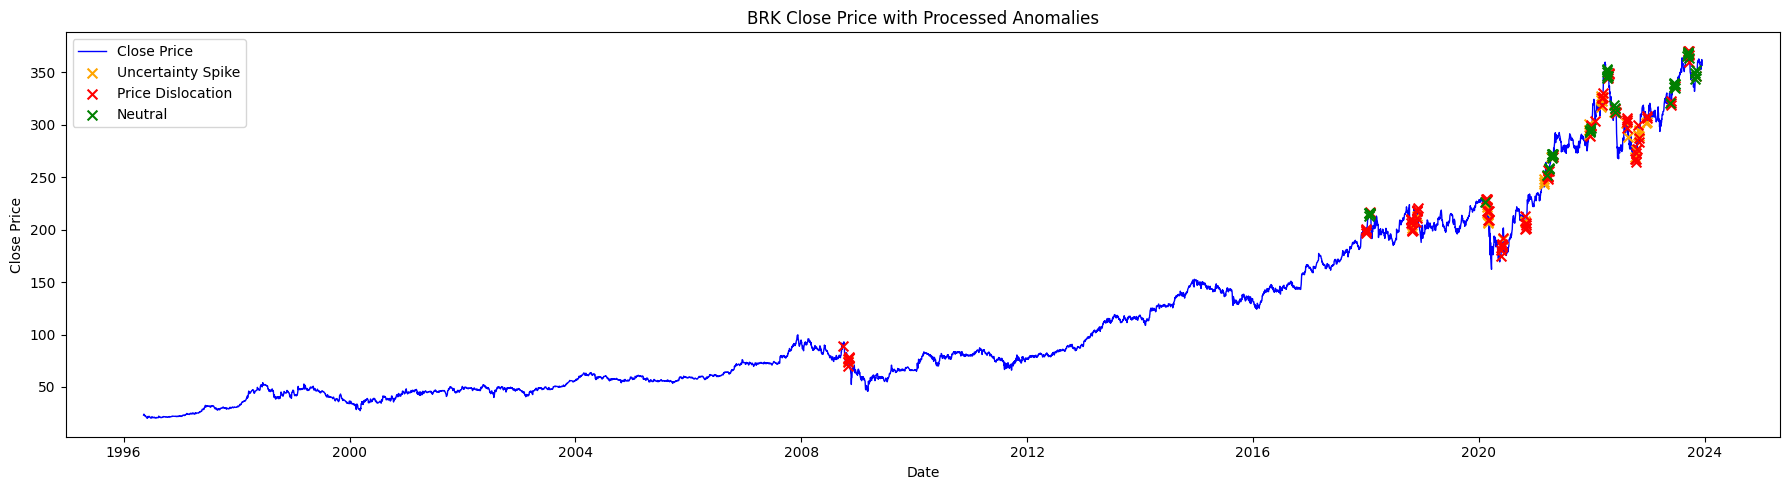

In [22]:
# Create graph
fig, ax = plt.subplots(figsize=(18, 5))

# Blue Graph: Plot 'close price' from 'tspulse_result_df' DataFrame
ax.plot(tspulse_result_df["date"], tspulse_result_df["close"], color="blue", linewidth=1, label="Close Price")

# Colors for each anomaly type
colors = {
    "uncertainty_spike": "orange",
    "price_dislocation": "red",
    "neutral": "green"
}

# Plot each anomaly type 
for anomaly_type, color in colors.items():
    subset = anomalies_processed_df[
        (anomalies_processed_df["anomaly_smooth_flag"] == 1) & 
        (anomalies_processed_df["anomaly_type"] == anomaly_type)]
    ax.scatter(
        subset["date"],
        subset["close"],
        color=color,
        s=50,
        marker="x",
        label=anomaly_type.replace("_", " ").title(),
        zorder=5
    )

ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
ax.set_title("BRK Close Price with Processed Anomalies")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

---

# Save Processed Anomalies

In [23]:
anomalies_to_save = anomalies_processed_df[["date", "anomaly_type", "anomaly_persistent"]]

anomalies_to_save.to_csv("./Outputs/BRK_anomalies_processed.csv", index=False)

print("Saved to 'BRK_anomalies_processed.csv'")

Saved to 'BRK_anomalies_processed.csv'
